In [444]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [445]:
df = pd.read_csv('Salary_Data (1).csv')
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [446]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [447]:
df.shape

(6704, 6)

In [448]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 552.7 KB


In [449]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [450]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [451]:
df.dropna(inplace = True)

In [452]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [453]:
df['Job Title'].value_counts()

Job Title
Software Engineer                518
Data Scientist                   453
Software Engineer Manager        376
Data Analyst                     363
Senior Project Engineer          318
                                ... 
Junior Research Scientist          1
Senior HR Specialist               1
Junior Operations Coordinator      1
Junior Financial Advisor           1
Social Media Man                   1
Name: count, Length: 191, dtype: int64

In [454]:
job_title_counts = df['Job Title'].value_counts()
job_title_edited = job_title_counts[job_title_counts <= 25]
job_title_edited.count()

np.int64(142)

In [455]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'Others' if x in job_title_edited else x)
df['Job Title'].nunique()

50

In [456]:
df['Education Level'].value_counts()

Education Level
Bachelor's Degree    2265
Master's Degree      1572
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [457]:
#

In [458]:
df['Education Level'] = df['Education Level'].replace(["Bachelor's Degree", "Master's Degree", "PhD"] , ["Bachelor's", "Master's", "phD"] , inplace=True)

In [459]:
df['Education Level'].value_counts()

Education Level
Bachelor's     3021
Master's       1860
phD            1369
High School     448
Name: count, dtype: int64

In [460]:
df['Gender'].value_counts()

Gender
Male      3671
Female    3013
Other       14
Name: count, dtype: int64

# EDA

<Axes: xlabel='Education Level', ylabel='count'>

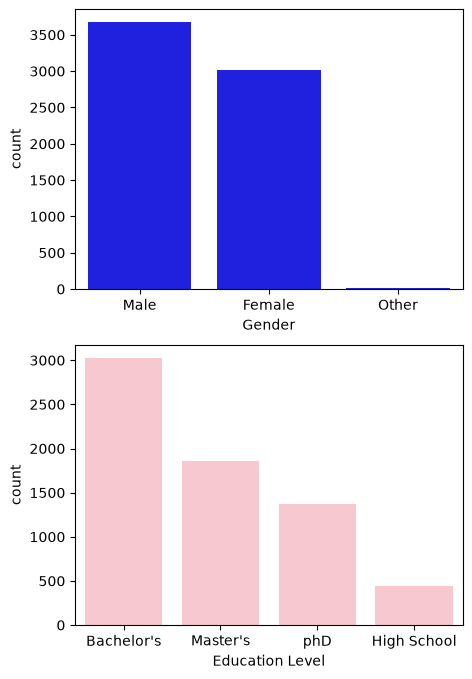

In [461]:
fig,ax = plt.subplots(2,1,figsize = (5,8))
sns.countplot(x= 'Gender', data=df, ax=ax[0] , color='blue')
sns.countplot(x='Education Level', data=df,  ax=ax[1] , color='pink')

<Axes: xlabel='Salary', ylabel='Count'>

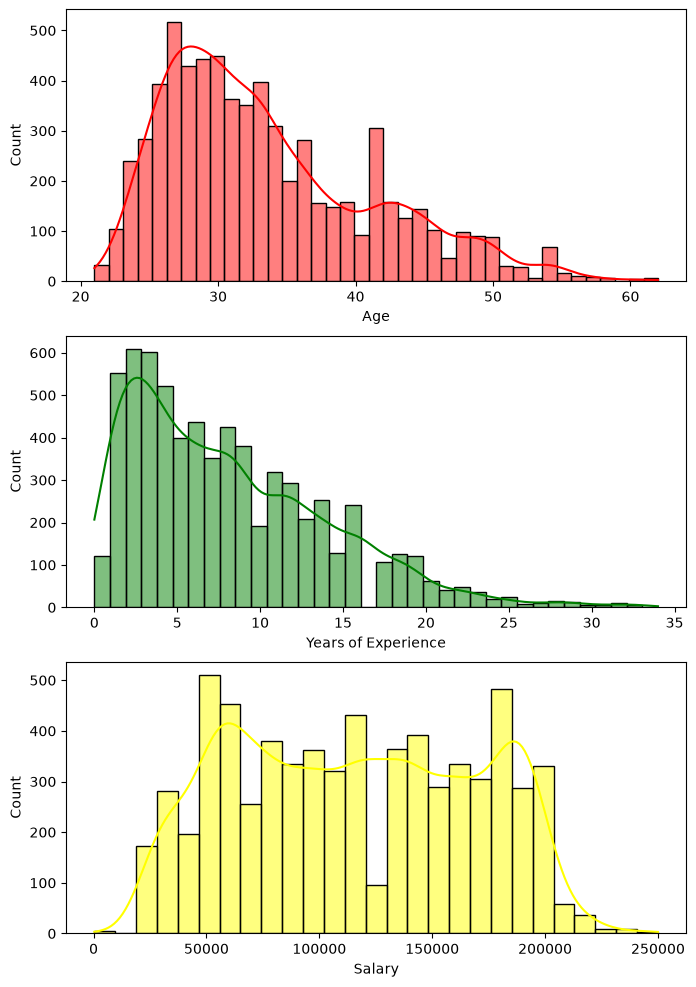

In [462]:
fig,ax = plt.subplots(3,1,figsize = (8,12))
sns.histplot(df['Age'], kde=True, ax=ax[0], color='red')
sns.histplot(df['Years of Experience'], kde=True, ax=ax[1], color='green')
sns.histplot(df['Salary'], kde=True, ax=ax[2] , color='yellow')

In [463]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [464]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [499]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'].astype(str))

In [500]:
X

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,Bachelor's,Software Engineer,5.0
1,28.0,0,Master's,Data Analyst,3.0
2,45.0,1,phD,Others,15.0
3,36.0,0,Bachelor's,Sales Associate,7.0
4,52.0,1,Master's,Others,20.0
...,...,...,...,...,...
6699,49.0,0,phD,Director of Marketing,20.0
6700,32.0,1,High School,Sales Associate,3.0
6701,30.0,0,Bachelor's,Financial Manager,4.0
6702,46.0,1,Master's,Marketing Manager,14.0


In [501]:
x_one_encoded = pd.get_dummies(columns=['Job Title', 'Education Level'], drop_first=True, data=X)
x_one_encoded = x_one_encoded.astype(dtype=int, errors = 'ignore')

In [502]:
x_one_encoded

,Age,Gender,Years of Experience,Job Title_Content Marketing Manager,Job Title_Data Analyst,Job Title_Data Scientist,Job Title_Digital Marketing Manager,Job Title_Director of Data Science,Job Title_Director of HR,Job Title_Director of Marketing,...,Job Title_Senior Project Engineer,Job Title_Senior Research Scientist,Job Title_Senior Software Engineer,Job Title_Software Developer,Job Title_Software Engineer,Job Title_Software Engineer Manager,Job Title_Web Developer,Education Level_High School,Education Level_Master's,Education Level_phD
0,32,1,5,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,28,0,3,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,45,1,15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,36,0,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52,1,20,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,49,0,20,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
6700,32,1,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6701,30,0,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6702,46,1,14,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [503]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Age', 'Years of Experience']
scaler = StandardScaler()
x_one_encoded[numerical_cols] = scaler.fit_transform(x_one_encoded[numerical_cols])

In [504]:
x_one_encoded

,Age,Gender,Years of Experience,Job Title_Content Marketing Manager,Job Title_Data Analyst,Job Title_Data Scientist,Job Title_Digital Marketing Manager,Job Title_Director of Data Science,Job Title_Director of HR,Job Title_Director of Marketing,...,Job Title_Senior Project Engineer,Job Title_Senior Research Scientist,Job Title_Senior Software Engineer,Job Title_Software Developer,Job Title_Software Engineer,Job Title_Software Engineer Manager,Job Title_Web Developer,Education Level_High School,Education Level_Master's,Education Level_phD
0,-0.213129,1,-0.510515,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,-0.738393,0,-0.840497,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1.493980,1,1.139392,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.312135,0,-0.180534,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2.413192,1,1.964345,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,2.019244,0,1.964345,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
6700,-0.213129,1,-0.840497,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6701,-0.475761,0,-0.675506,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6702,1.625296,1,0.974401,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [505]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [506]:
X_train, X_test, y_train, y_test = train_test_split( x_one_encoded, y, test_size=0.33, random_state=42)

In [507]:
models = {
    "Linear_Regression": LinearRegression(),
    "Decision_Tree": DecisionTreeRegressor(),
    "Random_Forest": RandomForestRegressor(),
}

In [508]:
results = []

In [509]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "r2_score": r2_score(y_test,y_pred)
    })

In [510]:
results

[{'model': 'Linear_Regression',
  'MAE': 15751.709129741,
  'MSE': 466804327.91398036,
  'r2_score': 0.8351803356589376},
 {'model': 'Decision_Tree',
  'MAE': 3314.5490556664117,
  'MSE': 95001303.36140735,
  'r2_score': 0.9664568599825065},
 {'model': 'Random_Forest',
  'MAE': 3491.6760123560957,
  'MSE': 74541231.70138697,
  'r2_score': 0.9736809192761899}]